# Formative 3 - Probability Distributions, Bayesian Probability, and Gradient Descent Implementation

# Part I

In [39]:
import matplotlib.pyplot as plt

def factorial(num):
    if num < 0:
        return 0
    elif num == 0:
        return 1
    else:
        factorial = 1
        for i in range(1, num + 1):
            factorial *= i
        return factorial

def binomial_coefficient(n, k):
    # The binomial coefficient counts the number of ways of choosing k objects from a set of n objects
    if k < 0 or k > n:
        return 0
    return factorial(n) // (factorial(k) * factorial(n - k))

def binomial_pmf(k, n, p):

    #k: number of successes
    #n: number of trials
    #p: probability of success on a single trial

    if not (0 <= p <= 1):
        raise ValueError("Probability p must be between 0 and 1.")
    if not (0 <= k <= n):
        return 0
    coeff = binomial_coefficient(n, k)
    probability = coeff * (p**k) * ((1 - p)**(n - k))
    return probability

Probability that exactly 2 students get 20/20: 0.1937


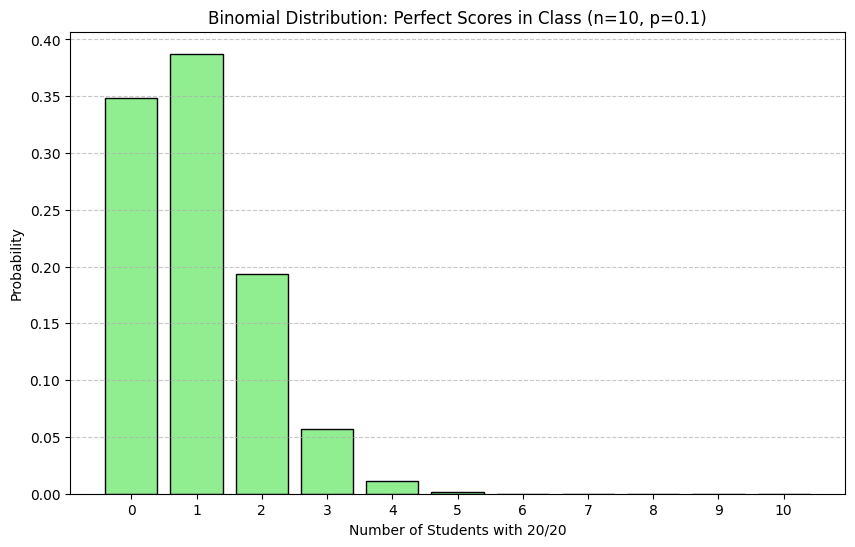

In [40]:
# Probability that exactly 2 out of 10 students get 20/20
n_students = 10
p_perfect = 0.1
k_target = 2

prob_2_perfect = binomial_pmf(k_target, n_students, p_perfect)
print(f"Probability that exactly 2 students get 20/20: {prob_2_perfect:.4f}")

# Visualize the distribution 
k_values_students = list(range(n_students + 1))
probabilities_students = [binomial_pmf(k, n_students, p_perfect) for k in k_values_students]

plt.figure(figsize=(10, 6))
plt.bar(k_values_students, probabilities_students, color='lightgreen', edgecolor='black')
plt.title(f'Binomial Distribution: Perfect Scores in Class (n={n_students}, p={p_perfect})')
plt.xlabel('Number of Students with 20/20')
plt.ylabel('Probability')
plt.xticks(k_values_students)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Part II

## Application of Bayesian probability in a real-world scenario - Medical Analysis

--- Bayesian Medical Diagnosis ---
Prior Probability of having Disease X (P(DiseaseX)): 0.0100
Likelihood of Positive Test given Disease X (P(Positive | DiseaseX)): 0.9500
Likelihood of Positive Test given NO Disease X (P(Positive | No DiseaseX)): 0.1000

Prior Probability of NOT having Disease X (P(No DiseaseX)): 0.9900

Evidence (P(Positive) - Total probability of a positive test): 0.1085

Posterior Probability of having Disease X given a POSITIVE test (P(DiseaseX | Positive)): 0.0876

--- Sequential Updates (Hypothetical Second Test) ---
New Prior (from first test's posterior): 0.0876
New Evidence (P(Positive) with new prior): 0.1744
New Posterior (after hypothetical second positive test): 0.4769


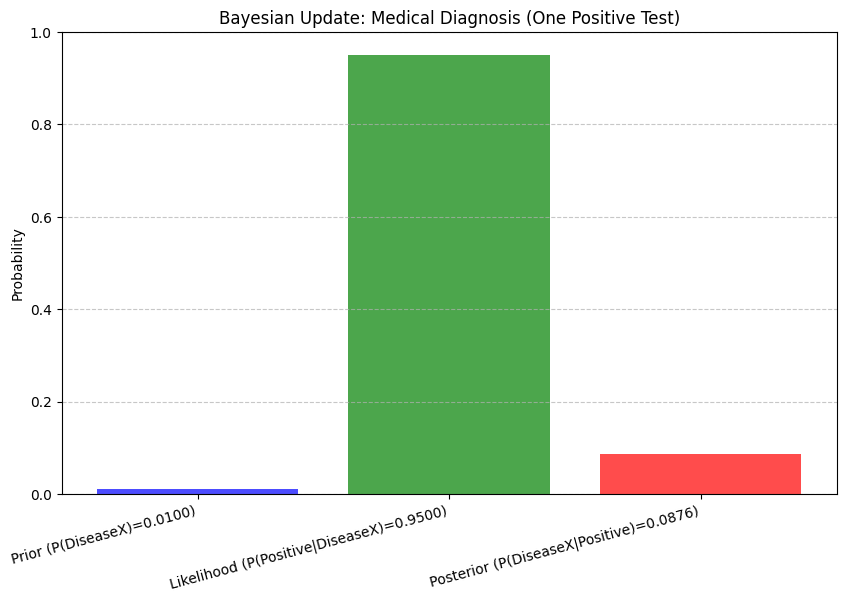


--- Sequential Posterior Probabilities after multiple hypothetical positive tests ---
Initial Prior: 0.0100
Posterior after 1 positive test(s): 0.0876
Posterior after 2 positive test(s): 0.4769
Posterior after 3 positive test(s): 0.8965
Posterior after 4 positive test(s): 0.9880
Posterior after 5 positive test(s): 0.9987


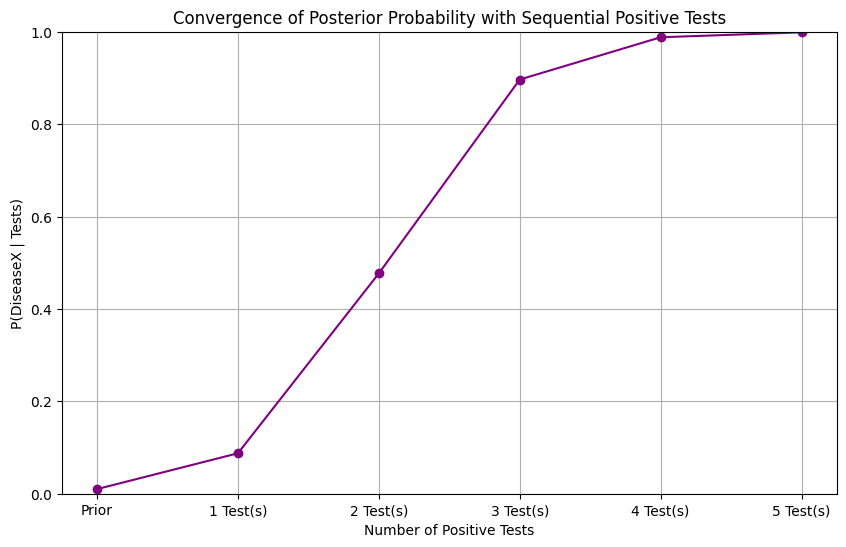

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Bayesian probability of having a given disease based on a medical test

# Prior Probability of having Disease X and the hypothetical test characteristics
prior_disease = 0.01
likelihood_positive_given_disease = 0.95
specificity_negative_given_no_disease = 0.90
likelihood_positive_given_no_disease = 1 - specificity_negative_given_no_disease

print("--- Bayesian Medical Diagnosis ---")
print(f"Prior Probability of having Disease X (P(DiseaseX)): {prior_disease:.4f}")
print(f"Likelihood of Positive Test given Disease X (P(Positive | DiseaseX)): {likelihood_positive_given_disease:.4f}")
print(f"Likelihood of Positive Test given NO Disease X (P(Positive | No DiseaseX)): {likelihood_positive_given_no_disease:.4f}\n")

prob_no_disease = 1 - prior_disease
print(f"Prior Probability of NOT having Disease X (P(No DiseaseX)): {prob_no_disease:.4f}")

# 2. The marginal likelihood of getting a positive test result
evidence_positive = (likelihood_positive_given_disease * prior_disease) +  (likelihood_positive_given_no_disease * prob_no_disease)
print(f"\nEvidence (P(Positive) - Total probability of a positive test): {evidence_positive:.4f}")

# 3. Apply Bayes' Theorem: Posterior Probability
posterior_disease_given_positive = (likelihood_positive_given_disease * prior_disease) / evidence_positive
print(f"\nPosterior Probability of having Disease X given a POSITIVE test (P(DiseaseX | Positive)): {posterior_disease_given_positive:.4f}")

print("\n--- Sequential Updates (Hypothetical Second Test) ---")

new_prior_disease = posterior_disease_given_positive

print(f"New Prior (from first test's posterior): {new_prior_disease:.4f}")

new_evidence_positive = (likelihood_positive_given_disease * new_prior_disease) + \
                        (likelihood_positive_given_no_disease * (1 - new_prior_disease))

print(f"New Evidence (P(Positive) with new prior): {new_evidence_positive:.4f}")

new_posterior_disease_given_positive = (likelihood_positive_given_disease * new_prior_disease) / new_evidence_positive

print(f"New Posterior (after hypothetical second positive test): {new_posterior_disease_given_positive:.4f}")


# Visualization

initial_prior = 0.01

prob_positive_given_disease = 0.95

prob_positive_given_no_disease = 0.10

p_positive_test = (prob_positive_given_disease * initial_prior) + \
                  (prob_positive_given_no_disease * (1 - initial_prior))
posterior_after_first_positive = (prob_positive_given_disease * initial_prior) / p_positive_test

labels = ['Initial Prior (P(DiseaseX))', 'Likelihood (P(Positive|DiseaseX))', 'Posterior (P(DiseaseX|Positive))']
values = [initial_prior, prob_positive_given_disease, posterior_after_first_positive]
labels_single_test = [
    f"Prior (P(DiseaseX)={initial_prior:.4f})",
    f"Likelihood (P(Positive|DiseaseX)={prob_positive_given_disease:.4f})",
    f"Posterior (P(DiseaseX|Positive)={posterior_after_first_positive:.4f})"
]

plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(labels_single_test))
plt.bar(bar_positions, values, color=['blue', 'green', 'red'], alpha=0.7)
plt.ylabel('Probability')
plt.title('Bayesian Update: Medical Diagnosis (One Positive Test)')
plt.xticks(bar_positions, labels_single_test, rotation=15, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

num_hypothetical_tests = 5
posterior_history = [initial_prior]

current_prior = initial_prior

for i in range(num_hypothetical_tests):
    current_evidence_positive = (prob_positive_given_disease * current_prior) + \
                                (prob_positive_given_no_disease * (1 - current_prior))
    
    current_posterior = (prob_positive_given_disease * current_prior) / current_evidence_positive

    posterior_history.append(current_posterior)
    current_prior = current_posterior


print("\n--- Sequential Posterior Probabilities after multiple hypothetical positive tests ---")
for i, prob in enumerate(posterior_history):
    if i == 0:
        print(f"Initial Prior: {prob:.4f}")
    else:
        print(f"Posterior after {i} positive test(s): {prob:.4f}")


# Plotting the convergence of posterior probabilities with sequential positive tests
plt.figure(figsize=(10, 6))
plt.plot(range(len(posterior_history)), posterior_history, marker='o', linestyle='-', color='purple')
plt.title('Convergence of Posterior Probability with Sequential Positive Tests')
plt.xlabel('Number of Positive Tests')
plt.ylabel('P(DiseaseX | Tests)')
plt.xticks(range(len(posterior_history)), [f'Prior'] + [f'{i+1} Test(s)' for i in range(num_hypothetical_tests)])
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Part 4

 Gradient Descent in Code 


Manual Gradient Descent (4 iterations):
After Iteration 1: m=1.7000, b=2.1000
After Iteration 2: m=1.2600, b=1.9000
After Iteration 3: m=1.3400, b=1.9160
After Iteration 4: m=1.3336, b=1.8968


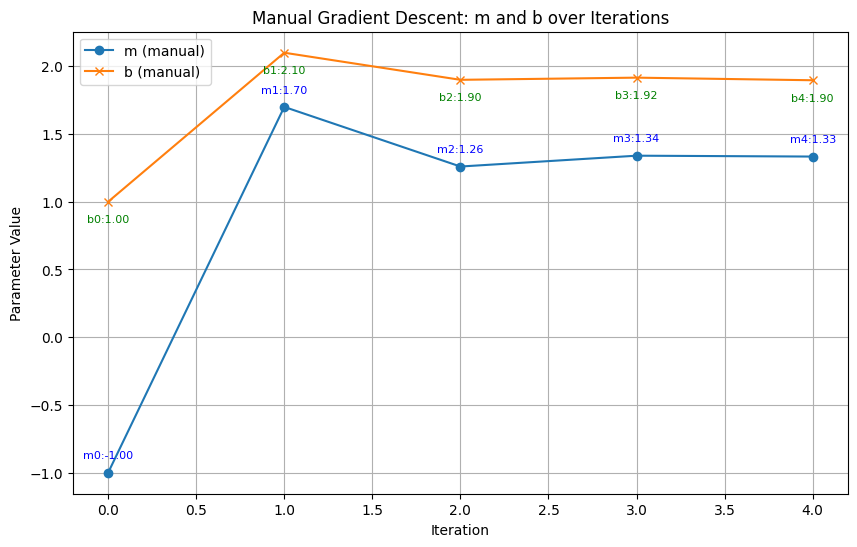

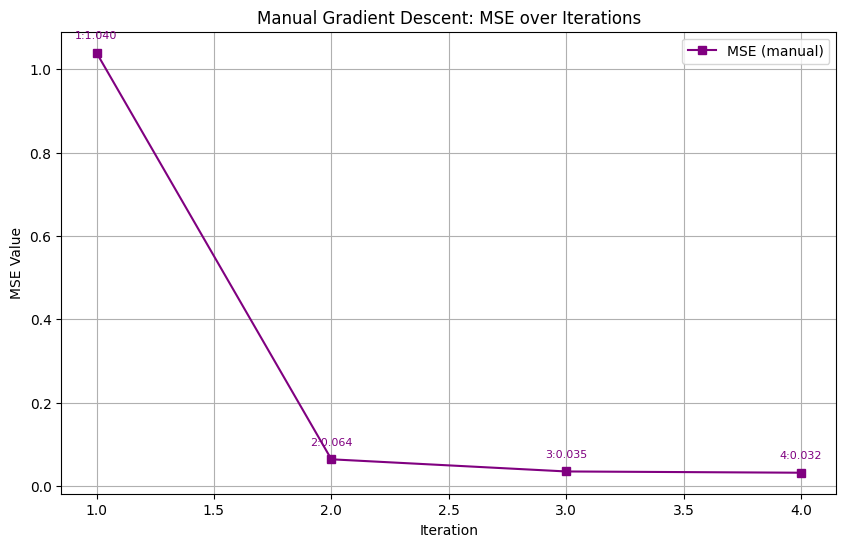

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([1, 3])
Y = np.array([3, 6])
m_initial = -1
b_initial = 1

# Use the exact values for m and b at each iteration (as requested)
m_manual_history = [-1, 1.7, 1.26, 1.34, 1.3336]
b_manual_history = [1, 2.1, 1.9, 1.916, 1.8968]
iterations = range(len(m_manual_history))

print("\nManual Gradient Descent (4 iterations):")
for i in range(1, 5):
    print(f"After Iteration {i}: m={m_manual_history[i]:.4f}, b={b_manual_history[i]:.4f}")

# Plot m and b over manual iterations, with annotation for each point
plt.figure(figsize=(10, 6))
plt.plot(iterations, m_manual_history, label='m (manual)', marker='o', markersize=6)
plt.plot(iterations, b_manual_history, label='b (manual)', marker='x', markersize=6)
for i, (m_val, b_val) in enumerate(zip(m_manual_history, b_manual_history)):
    plt.annotate(f"m{i}:{m_val:.2f}", (i, m_val), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='blue')
    plt.annotate(f"b{i}:{b_val:.2f}", (i, b_val), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8, color='green')
plt.xlabel('Iteration')
plt.ylabel('Parameter Value')
plt.title('Manual Gradient Descent: m and b over Iterations')
plt.legend()
plt.grid(True)
plt.show()

# Plot MSE over manual iterations (recalculate using the fixed m and b values)
mse_manual_history = []
for m, b in zip(m_manual_history[1:], b_manual_history[1:]):
    mse = np.mean((Y - (m * X + b))**2)
    mse_manual_history.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mse_manual_history)+1), mse_manual_history, label='MSE (manual)', color='purple', marker='s', markersize=6)
for i, mse_val in enumerate(mse_manual_history, 1):
    plt.annotate(f"{i}:{mse_val:.3f}", (i, mse_val), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='purple')
plt.xlabel('Iteration')
plt.ylabel('MSE Value')
plt.title('Manual Gradient Descent: MSE over Iterations')
plt.legend()
plt.grid(True)
plt.show()